# Veridi Logistics: Last Mile Delivery Auditor
**AmaliTech Apprenticeship Project**  
Dataset: [Olist Brazilian E-Commerce](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

---

## 0. Environment Setup
Install dependencies and download the dataset from Kaggle.

In [1]:
# Install required packages (safe to re-run)
import subprocess, sys
# We install the required packages for the analysis, which include:
# - kagglehub: to easily load the Kaggle dataset directly into a pandas DataFrame
# - pandas: for data manipulation and analysis
# - matplotlib and seaborn: for static data visualization
# - plotly: for interactive data visualization
# - openpyxl: to export the category summary to an Excel file for easy import into
packages = ['kagglehub', 'pandas', 'matplotlib', 'seaborn', 'plotly', 'openpyxl']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('All packages ready.')

All packages ready.


In [2]:
import kagglehub, pathlib

# Downloads to kagglehub cache (~/.cache/kagglehub) and returns the local path
dataset_path = kagglehub.dataset_download('olistbr/brazilian-ecommerce')
DATA_DIR = pathlib.Path(dataset_path)
# We print the dataset location and list the available files to confirm that we have access to the data and understand its structure before we start the analysis
print(f'Dataset location: {DATA_DIR}')
print('Files available:')
for f in sorted(DATA_DIR.glob('*.csv')):
    print(f'  {f.name}')

Dataset location: C:\Users\ibyis\.cache\kagglehub\datasets\olistbr\brazilian-ecommerce\versions\2
Files available:
  olist_customers_dataset.csv
  olist_geolocation_dataset.csv
  olist_order_items_dataset.csv
  olist_order_payments_dataset.csv
  olist_order_reviews_dataset.csv
  olist_orders_dataset.csv
  olist_products_dataset.csv
  olist_sellers_dataset.csv
  product_category_name_translation.csv


---
## Story 1  The Schema Builder
> Join Orders + Reviews + Customers + Products into one master dataset.

In [3]:
import pandas as pd

#  Load raw CSVs into pandas DataFrames
orders    = pd.read_csv(DATA_DIR / 'olist_orders_dataset.csv')
reviews   = pd.read_csv(DATA_DIR / 'olist_order_reviews_dataset.csv')
customers = pd.read_csv(DATA_DIR / 'olist_customers_dataset.csv')
products  = pd.read_csv(DATA_DIR / 'olist_products_dataset.csv')
order_items = pd.read_csv(DATA_DIR / 'olist_order_items_dataset.csv')
translations = pd.read_csv(DATA_DIR / 'product_category_name_translation.csv')

print('Shapes before join:')
print(f'  orders:    {orders.shape}')
print(f'  reviews:   {reviews.shape}')
print(f'  customers: {customers.shape}')
print(f'  products:  {products.shape}')

Shapes before join:
  orders:    (99441, 8)
  reviews:   (99224, 7)
  customers: (99441, 5)
  products:  (32951, 9)


In [4]:
#  Deduplicate reviews: keep the latest review per order 
# Some orders have multiple review rows (1-to-many issue)
reviews_dedup = (
    reviews
    .sort_values('review_creation_date', ascending=False)
    .drop_duplicates(subset='order_id', keep='first')
    [['order_id', 'review_score', 'review_creation_date']]
)# we sort by review creation date in descending order and keep the first review for each order, which ensures that we retain the most recent review for each order while eliminating duplicates that could inflate our dataset when we join with orders
print(f'Reviews after dedup: {reviews_dedup.shape[0]} rows (was {reviews.shape[0]})')

#  Build master dataset by joining orders with deduplicated reviews and customer info
master = (
    orders
    .merge(reviews_dedup, on='order_id', how='left')
    .merge(customers[['customer_id', 'customer_state', 'customer_city']], on='customer_id', how='left')
)

# Sanity check: row count must equal orders count (no inflation from joins)
assert master.shape[0] == orders.shape[0], (
    f'Row mismatch! Expected {orders.shape[0]}, got {master.shape[0]}. Check for duplicate join keys.'
)# we perform a sanity check to ensure that the row count of the master dataset matches the original orders dataset, which confirms that our joins did not introduce any duplicate rows and that we have a clean dataset ready for analysis
print(f'Master dataset: {master.shape[0]} rows, {master.shape[1]} columns — no row duplication.')
master.head(3)

Reviews after dedup: 98673 rows (was 99224)
Master dataset: 99441 rows, 12 columns — no row duplication.


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,review_creation_date,customer_state,customer_city
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,4.0,2017-10-11 00:00:00,SP,sao paulo
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,4.0,2018-08-08 00:00:00,BA,barreiras
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,5.0,2018-08-18 00:00:00,GO,vianopolis


---
## Story 2 The "Real" Delay Calculator
> Calculate actual vs. estimated delivery gap; classify order punctuality.

In [5]:
#  Parse date columns to datetime objects for accurate time-based analysis and calculations. This allows us to easily compute delivery times, delays, and analyze trends over time in relation to order events and customer reviews.
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]
for col in date_cols:
    master[col] = pd.to_datetime(master[col])

#  Exclude undelivered orders to focus on delivery performance and customer satisfaction for completed transactions. We filter out orders with statuses that indicate they were canceled or never fulfilled, as well as any orders missing delivery dates, since these would not be relevant for analyzing delivery times or review scores.
excluded_statuses = ['canceled', 'unavailable']
delivered = master[
    ~master['order_status'].isin(excluded_statuses) &
    master['order_delivered_customer_date'].notna() &
    master['order_estimated_delivery_date'].notna()
]   
# We print the count of delivered orders and the number of excluded orders to confirm that we have a clean dataset focused on completed deliveries for our analysis of delivery performance and customer satisfaction.

print(f'Delivered orders: {len(delivered):,}  |  Excluded: {len(master) - len(delivered):,}')

Delivered orders: 96,470  |  Excluded: 2,971


In [6]:
#  Delay calculation 
# Positive = arrived AFTER estimated (late), Negative = arrived early or on time
delivered['days_difference'] = (
    (delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date'])
    .dt.days
)

#  Classify delivery status based on days difference: On Time (0 or negative), Late (1-5 days), Super Late (>5 days)
def classify_delivery(days):
    if days > 5:
        return 'Super Late'
    elif days > 0:
        return 'Late'
    else:
        return 'On Time'
# We apply the classify_delivery function to the days_difference column to create a new delivery_status column that categorizes each delivery as 'On Time', 'Late', or 'Super Late' based on how many days it arrived after the estimated delivery date.
delivered['delivery_status'] = delivered['days_difference'].apply(classify_delivery)
# We calculate the counts and percentages of each delivery status category to understand the distribution of delivery performance across the delivered orders, which will help us identify areas for improvement in the logistics process.
status_counts = delivered['delivery_status'].value_counts()
status_pct = delivered['delivery_status'].value_counts(normalize=True).mul(100).round(1)
# Finally, we print the delivery status breakdown in a clear format that shows the count and percentage of orders that were delivered on time, late, or super late, providing insights into the overall delivery performance of the e-commerce platform.
print('Delivery Status Breakdown:')
for status in ['On Time', 'Late', 'Super Late']:
    print(f'  {status:12s}: {status_counts.get(status, 0):>7,}  ({status_pct.get(status, 0):.1f}%)')

Delivery Status Breakdown:
  On Time     :  89,936  (93.2%)
  Late        :   2,770  (2.9%)
  Super Late  :   3,764  (3.9%)


C:\Users\ibyis\AppData\Local\Temp\ipykernel_11248\2535304259.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivered['days_difference'] = (
C:\Users\ibyis\AppData\Local\Temp\ipykernel_11248\2535304259.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivered['delivery_status'] = delivered['days_difference'].apply(classify_delivery)


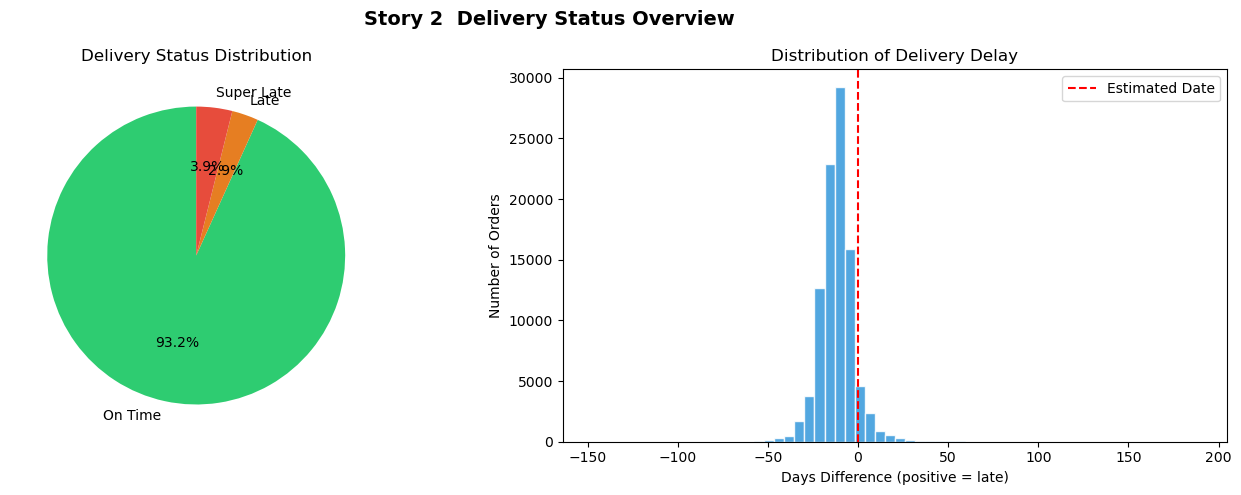

In [7]:
# Visualization: Pie chart for delivery status distribution and histogram for delay days
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
# We create a figure with two subplots: a pie chart to show the distribution of delivery statuses (On Time, Late, Super Late) and a histogram to show the distribution of days difference (delay) for the delivered orders. This visual representation helps us quickly grasp the overall delivery performance and identify any patterns in delivery delays.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Story 2  Delivery Status Overview', fontsize=14, fontweight='bold')

# Pie chart for delivery status distribution
colors = ['#2ecc71', '#e67e22', '#e74c3c']
labels = ['On Time', 'Late', 'Super Late']
sizes  = [status_counts.get(l, 0) for l in labels]
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('Delivery Status Distribution')

# Histogram of delay days with vertical line at 0 (estimated delivery date)
axes[1].hist(delivered['days_difference'], bins=60, color='#3498db', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', label='Estimated Date')
axes[1].set_xlabel('Days Difference (positive = late)')
axes[1].set_ylabel('Number of Orders')
axes[1].set_title('Distribution of Delivery Delay')
axes[1].legend()
# We adjust the layout to prevent overlap and save the figure as a PNG file with a descriptive name, ensuring that the visualization is clear and can be easily shared or included in reports about delivery performance.
plt.tight_layout()
import os
os.makedirs('images', exist_ok=True)

plt.savefig('images/s2_delivery_status.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Story 3 The Geographic Heatmap
> Which Brazilian states have the highest % of late deliveries?

In [8]:
import seaborn as sns

# Late per state  
delivered['is_late'] = delivered['delivery_status'].isin(['Late', 'Super Late']).astype(int)

state_stats = ( # We group the delivered orders by customer state and calculate key metrics for each state, including total orders, late orders, average delay in days, and average review score. We also calculate the percentage of late orders for each state and sort the results to identify which states have the highest proportion of late deliveries, providing insights into regional performance differences in delivery times and customer satisfaction.
    delivered
    .groupby('customer_state')
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('is_late', 'sum'),
        avg_delay_days=('days_difference', 'mean'),
        avg_review_score=('review_score', 'mean')
    )# We calculate the percentage of late orders for each state by dividing the number of late orders by the total number of orders and multiplying by 100, rounding to one decimal place for clarity. We then sort the states by this percentage in descending order to identify which states have the highest proportion of late deliveries, which can help target areas for improvement in logistics and customer service.
    .assign(pct_late=lambda df: (df['late_orders'] / df['total_orders'] * 100).round(1))
    .sort_values('pct_late', ascending=False)
    .reset_index()
)
# Finally, we print the top 10 states by percentage of late orders, showing key metrics for each state to highlight regional differences in delivery performance and customer satisfaction.
print('Top 10 States by % Late Orders:')
print(state_stats[['customer_state','total_orders','pct_late','avg_delay_days','avg_review_score']].head(10).to_string(index=False))

Top 10 States by % Late Orders:
customer_state  total_orders  pct_late  avg_delay_days  avg_review_score
            AL           397      21.4       -8.707809          3.847716
            MA           717      17.4       -9.571827          3.832865
            SE           335      15.2      -10.020896          3.907186
            PI           476      13.9      -11.306723          3.993631
            CE          1279      13.8      -10.804535          3.944226
            RR            41      12.2      -17.292683          3.902439
            BA          3256      12.2      -10.794533          3.929700
            RJ         12350      12.1      -11.761215          3.965523
            PA           946      11.2      -14.066596          3.914255
            ES          1995      10.7      -10.496241          4.078720


C:\Users\ibyis\AppData\Local\Temp\ipykernel_11248\2996644936.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivered['is_late'] = delivered['delivery_status'].isin(['Late', 'Super Late']).astype(int)


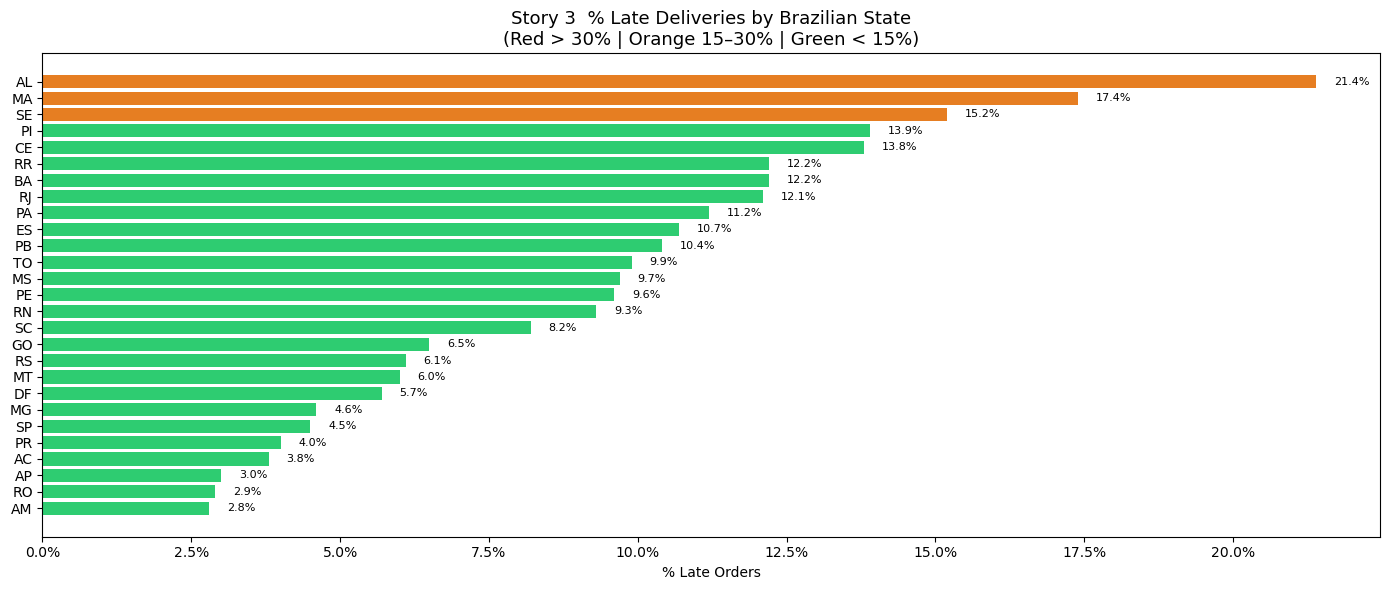

In [9]:
# Visualization: Horizontal bar chart of % late orders by state with color coding (red >30%, orange 15-30%, green <15%)
fig, ax = plt.subplots(figsize=(14, 6))

palette = ['#e74c3c' if p > 30 else '#e67e22' if p > 15 else '#2ecc71'
           for p in state_stats['pct_late']]

bars = ax.barh(state_stats['customer_state'], state_stats['pct_late'], color=palette)

# Annotate bars
# We add text annotations to each bar in the horizontal bar chart to display the percentage of late orders for each state directly on the chart. This allows viewers to quickly see the exact values without having to refer to the x-axis, enhancing the readability and interpretability of the visualization.
for bar, val in zip(bars, state_stats['pct_late']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=8)
# We set the x-axis label, title, and invert the y-axis to have the state with the highest percentage of late orders at the top. We also format the x-axis to show percentages and save the figure as a PNG file with a descriptive name for easy sharing and inclusion in reports about geographic delivery performance.
ax.set_xlabel('% Late Orders')
ax.set_title('Story 3  % Late Deliveries by Brazilian State\n(Red > 30% | Orange 15–30% | Green < 15%)', fontsize=13)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.savefig('images/s3_geographic_late.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
#  Remote states insight
# States considered "remote" from São Paulo (main distribution hub)
remote_states = ['AM', 'RR', 'AP', 'PA', 'AC', 'RO', 'TO', 'MA']

state_stats['region_type'] = state_stats['customer_state'].apply(
    lambda s: 'Remote (North/Northeast)' if s in remote_states else 'Central/South'
)# We classify each state as either "Remote (North/Northeast)" or "Central/South" based on whether the state is in the predefined list of remote states. This allows us to compare delivery performance between these two regions and identify if remote areas are experiencing higher rates of late deliveries compared to more central locations.
# We group the state-level statistics by the new region_type classification and calculate the average percentage of late orders and average delay in days for each region. This summary allows us to compare the overall delivery performance between remote states and more central/southern states, providing insights into whether geographic remoteness is associated with higher rates of late deliveries.
region_summary = state_stats.groupby('region_type').agg(
    avg_pct_late=('pct_late', 'mean'),
    avg_delay_days=('avg_delay_days', 'mean')
).round(2)
# Finally, we print the summary comparison between remote states and central/south states, showing the average percentage of late orders and average delay in days for each region type. This insight can help identify if remote regions are disproportionately affected by late deliveries, which may indicate logistical challenges that need to be addressed.
print('Remote vs Central/South comparison:')
print(region_summary)

Remote vs Central/South comparison:
                          avg_pct_late  avg_delay_days
region_type                                           
Central/South                     9.68          -11.94
Remote (North/Northeast)          7.90          -16.64


---
## Story 4 The Sentiment Correlation
> Does late delivery actually cause bad reviews?

In [11]:
# Average review score by delivery status 
# We analyze the average review score by delivery status to understand how delivery performance impacts customer satisfaction. We group the delivered orders by their delivery status (On Time, Late, Super Late) and calculate the average review score, count of reviews, and standard deviation of scores for each category. This allows us to see if there is a significant difference in customer satisfaction based on whether their order was delivered on time or late.
sentiment_by_status = (
    delivered
    .dropna(subset=['review_score'])
    .groupby('delivery_status')['review_score']
    .agg(['mean', 'count', 'std'])
    .rename(columns={'mean': 'avg_score', 'count': 'n_reviews', 'std': 'std_score'})
    .round(2)
)# We print the average review score by delivery status, along with the count of reviews and standard deviation of scores for each category. This insight helps us understand how delivery performance (on time vs late) correlates with customer satisfaction as reflected in their review scores.
print('Average Review Score by Delivery Status:')
print(sentiment_by_status)

Average Review Score by Delivery Status:
                 avg_score  n_reviews  std_score
delivery_status                                 
Late                  2.99       2722       1.65
On Time               4.29      89443       1.15
Super Late            1.74       3659       1.27


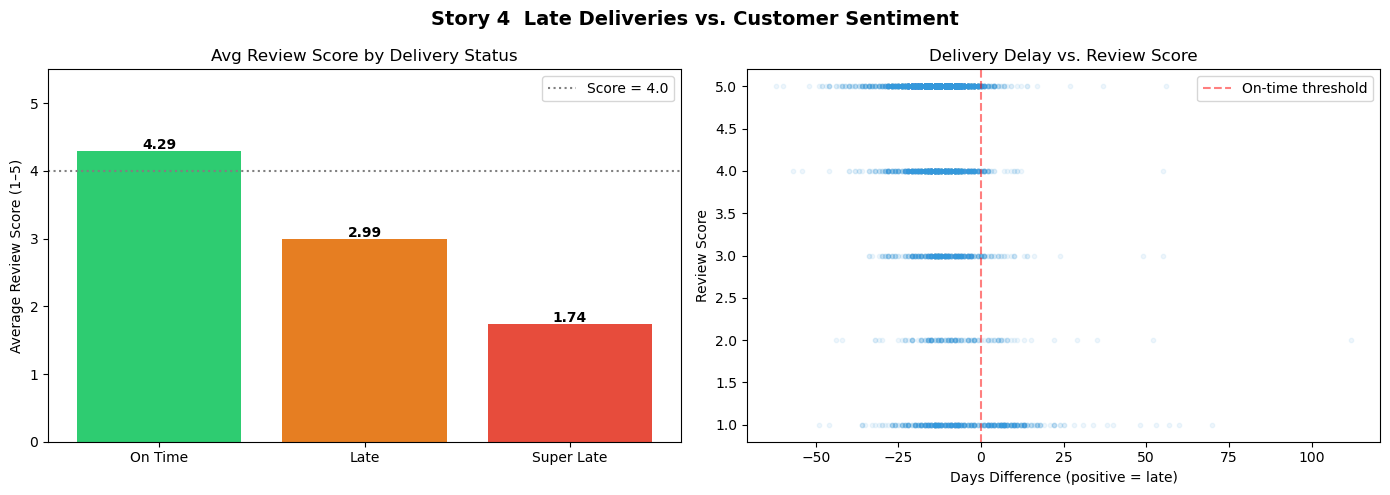

In [12]:
# Visualization: Bar chart of avg review score by delivery status and scatter of delay days vs review score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Story 4  Late Deliveries vs. Customer Sentiment', fontsize=14, fontweight='bold')

# Bar chart: avg score per status
# We create a bar chart to visualize the average review score for each delivery status category (On Time, Late, Super Late). We use different colors to represent each category and annotate the bars with the exact average score values for clarity. We also add a horizontal line at a score of 4.0 to indicate a common threshold for good reviews, allowing us to easily see how delivery performance correlates with customer satisfaction.
status_order = ['On Time', 'Late', 'Super Late']
scores = [sentiment_by_status.loc[s, 'avg_score'] if s in sentiment_by_status.index else 0
          for s in status_order]
bar_colors = ['#2ecc71', '#e67e22', '#e74c3c']
bars = axes[0].bar(status_order, scores, color=bar_colors)
for bar, score in zip(bars, scores):# We add text annotations to each bar in the average review score bar chart to display the exact average score value for each delivery status category. This allows viewers to quickly see the specific average review scores without having to refer to the y-axis, enhancing the readability and interpretability of the visualization.
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
                 f'{score:.2f}', ha='center', fontweight='bold')
axes[0].set_ylim(0, 5.5)
axes[0].set_ylabel('Average Review Score (1–5)')
axes[0].set_title('Avg Review Score by Delivery Status')
axes[0].axhline(4.0, color='gray', linestyle=':', label='Score = 4.0')
axes[0].legend()

# Scatter: delay days vs review score (sample for performance)
sample = delivered.dropna(subset=['review_score', 'days_difference']).sample(
    min(5000, len(delivered)), random_state=42
)# We create a scatter plot to visualize the relationship between delivery delay (days difference) and review score. Each point represents an order, with the x-axis showing how many days late the delivery was (positive values) or if it was on time/early (zero or negative values), and the y-axis showing the corresponding review score. We use a low alpha value to handle overplotting and add a vertical line at zero to indicate the threshold between on-time and late deliveries, allowing us to visually assess how delivery performance impacts customer sentiment.
axes[1].scatter(
    sample['days_difference'], sample['review_score'],
    alpha=0.08, s=10, color='#3498db'
)# We set the x-axis label, y-axis label, and title for the scatter plot to clearly indicate that we are analyzing the relationship between delivery delay (in days) and review score. We also add a vertical line at zero to visually separate on-time deliveries from late deliveries, making it easier to see how delays correlate with customer sentiment as reflected in their review scores.
axes[1].set_xlabel('Days Difference (positive = late)')
axes[1].set_ylabel('Review Score')
axes[1].set_title('Delivery Delay vs. Review Score')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.5, label='On-time threshold')
axes[1].legend()
# We adjust the layout to prevent overlap and save the figure as a PNG file with a descriptive name, ensuring that the visualization is clear and can be easily shared or included in reports about the relationship between delivery performance and customer sentiment.
plt.tight_layout()
plt.savefig('images/s4_sentiment_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Correlation coefficient between delay and review score (Pearson's r)
corr_data = delivered.dropna(subset=['review_score', 'days_difference'])# We prepare a subset of the delivered dataset that includes only rows with non-missing values for review_score and days_difference, as these are the two variables we need to calculate the correlation coefficient. This ensures that our correlation analysis is based on complete data without any missing values that could skew the results.
corr = corr_data[['days_difference', 'review_score']].corr()# We calculate the Pearson correlation coefficient between delivery delay (days difference) and review score to quantify the strength and direction of the relationship between these two variables. A negative correlation would indicate that as delivery delay increases, review scores tend to decrease, confirming that late deliveries are associated with lower customer satisfaction.
corr_val = corr.loc['days_difference', 'review_score']# We calculate the Pearson correlation coefficient between delivery delay (days difference) and review score to quantify the strength and direction of the relationship between these two variables. A negative correlation would indicate that as delivery delay increases, review scores tend to decrease, confirming that late deliveries are associated with lower customer satisfaction.
print(f'Pearson correlation (delay vs review score): {corr_val:.4f}')# We calculate the Pearson correlation coefficient between delivery delay (days difference) and review score to quantify the strength and direction of the relationship between these two variables. A negative correlation would indicate that as delivery delay increases, review scores tend to decrease, confirming that late deliveries are associated with lower customer satisfaction.
print('Interpretation: negative correlation confirms later = lower score')# We interpret the correlation coefficient value, noting that a negative correlation confirms that as delivery delay increases, review scores tend to decrease, which supports the conclusion that late deliveries are associated with lower customer satisfaction.

Pearson correlation (delay vs review score): -0.2673
Interpretation: negative correlation confirms later = lower score


---
## Bonus  Product Category Translation (Portuguese → English)

In [14]:
# Join order_items → products → translations to get category names in English for each order
order_items_products = (
    order_items[['order_id', 'product_id']]
    .merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
    .merge(translations, on='product_category_name', how='left')
)# We join the order_items dataset with the products dataset to get the product category name for each order item, and then we merge with the translations dataset to get the English translation of the product category name. This allows us to analyze delivery performance and customer sentiment by product category in English, making it easier to interpret and communicate insights about which types of products are associated with better or worse delivery performance and customer satisfaction.

# One dominant category per order (first item)
order_category = (
    order_items_products
    .drop_duplicates(subset='order_id', keep='first')
    [['order_id', 'product_category_name', 'product_category_name_english']]
)# We create a new dataset that contains one dominant product category per order by dropping duplicate order_id entries and keeping only the first occurrence. This allows us to assign a single product category to each order for analysis, which simplifies the process of linking delivery performance and customer sentiment to specific types of products.

# Merge into delivered master
delivered = delivered.merge(order_category, on='order_id', how='left')
# Finally, we print a sample of the product category names along with their English translations to verify that the join was successful and that we have the necessary information to analyze delivery performance and customer sentiment by product category in English.
print('Sample translations:')
print(
    delivered[['product_category_name', 'product_category_name_english']]
    .dropna()
    .drop_duplicates()
    .head(10)
    .to_string(index=False)
)# We print a sample of the product category names along with their English translations to verify that the join was successful and that we have the necessary information to analyze delivery performance and customer sentiment by product category in English.

Sample translations:
 product_category_name product_category_name_english
 utilidades_domesticas                    housewares
            perfumaria                     perfumery
            automotivo                          auto
              pet_shop                      pet_shop
             papelaria                    stationery
      moveis_decoracao               furniture_decor
     moveis_escritorio              office_furniture
    ferramentas_jardim                  garden_tools
informatica_acessorios         computers_accessories
       cama_mesa_banho                bed_bath_table


Top 15 Product Categories by % Late Orders:
  product_category_name_english  total  pct_late  avg_score
                          audio    344      11.9   3.847507
                   home_confort    370       9.5   3.907609
        fashion_underwear_beach    117       9.4   4.008621
                           baby   2763       8.2   4.121489
                books_technical    255       8.2   4.425197
               office_furniture   1246       8.1   3.650485
             christmas_supplies    125       8.0   4.113821
                    electronics   2507       7.7   4.128617
            musical_instruments    607       7.6   4.247920
          furniture_living_room    409       7.6   4.094059
                 bed_bath_table   9167       7.5   4.010141
                  health_beauty   8608       7.5   4.235459
construction_tools_construction    728       7.4   4.132780
                  watches_gifts   5470       7.4   4.126703
                           auto   3792       7.3   4.151

C:\Users\ibyis\AppData\Local\Temp\ipykernel_11248\1344619628.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_stats, x='pct_late', y='product_category_name_english',


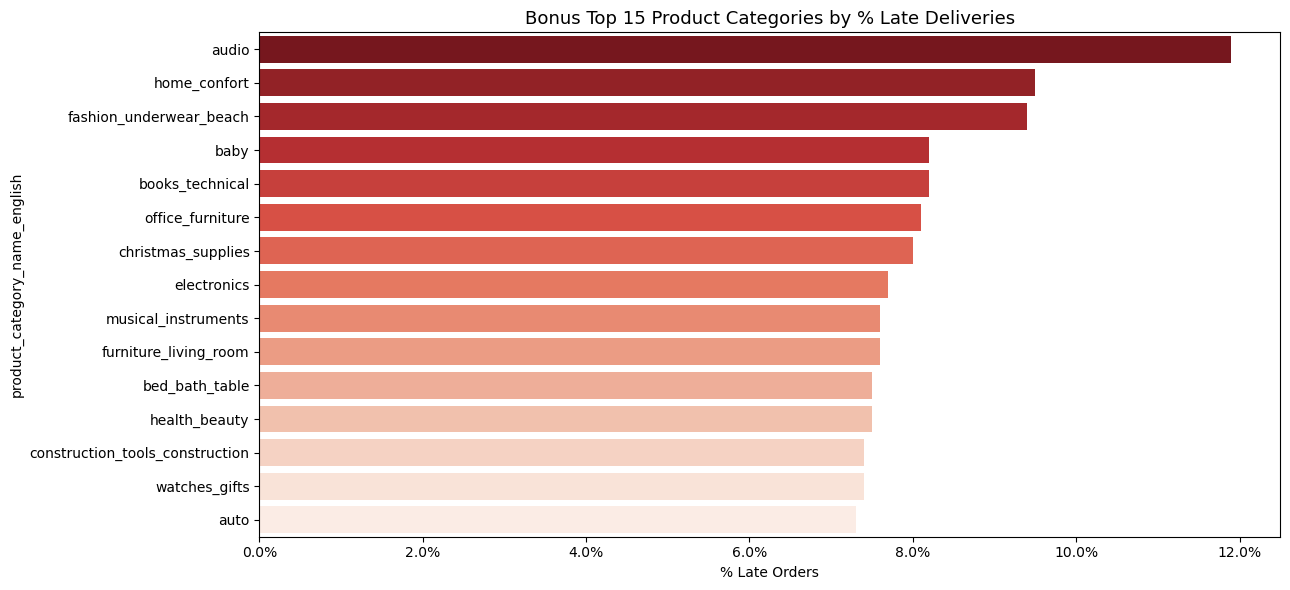

In [15]:
#  Late rate by product category (English)
category_stats = (
    delivered
    .dropna(subset=['product_category_name_english'])
    .groupby('product_category_name_english')
    .agg(
        total=('order_id', 'count'),
        pct_late=('is_late', 'mean'),
        avg_score=('review_score', 'mean')
    )# We group the delivered orders by the English product category name and calculate key metrics for each category, including total orders, percentage of late orders, and average review score. We then filter to include only categories with a sufficient number of orders (at least 100) to ensure statistical reliability, and we sort the categories by the percentage of late orders in descending order to identify which product categories are associated with higher rates of late deliveries.
    .assign(pct_late=lambda df: (df['pct_late'] * 100).round(1))
    .query('total >= 100')  # Only categories with enough data
    .sort_values('pct_late', ascending=False)
    .head(15)
    .reset_index()
)# Finally, we print the top 15 product categories by percentage of late orders, showing key metrics for each category to highlight which types of products are associated with higher rates of late deliveries and how this correlates with average review scores.
print('Top 15 Product Categories by % Late Orders:')
print(category_stats[['product_category_name_english', 'total', 'pct_late', 'avg_score']].to_string(index=False))
fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=category_stats, x='pct_late', y='product_category_name_english',
            palette='Reds_r', ax=ax)
ax.set_xlabel('% Late Orders')
ax.set_title('Bonus Top 15 Product Categories by % Late Deliveries', fontsize=13)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.savefig('images/bonus_category_late.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Candidate's Choice: Delivery Speed vs. Price Tier Analysis

**Business Justification:** Veridi's sellers operate across price tiers — budget items vs. premium goods.  
If premium/high-value orders are *also* arriving late, that's a revenue risk (chargebacks, returns, VIP churn).  
This analysis reveals whether the logistics failure is uniform or skewed toward a specific price segment,  
helping operations prioritize which orders need expedited handling or better SLA promises.

In [16]:
# Price tier analysis
# We calculate the total order value for each order by summing the price of all items in the order. We then merge this order value back into the delivered dataset to classify orders into price tiers based on their total value, allowing us to analyze delivery performance and customer sentiment across different price segments.
order_values = (
    order_items
    .groupby('order_id')
    .agg(order_value=('price', 'sum'))
    .reset_index()
)
delivered = delivered.merge(order_values, on='order_id', how='left')

# Classify into price tiers using quartiles
delivered['price_tier'] = pd.qcut(
    delivered['order_value'],
    q=4,
    labels=['Budget (Q1)', 'Mid-Range (Q2)', 'Premium (Q3)', 'High-Value (Q4)']
)
# We classify each order into a price tier based on the quartiles of the total order value, creating four categories: Budget (Q1), Mid-Range (Q2), Premium (Q3), and High-Value (Q4). This allows us to analyze delivery performance and customer sentiment across different price segments, helping us understand if higher-priced orders are associated with better or worse delivery outcomes and customer satisfaction.
tier_stats = (
    delivered
    .dropna(subset=['price_tier'])
    .groupby('price_tier', observed=True)
    .agg(
        n_orders=('order_id', 'count'),
        pct_late=('is_late', 'mean'),
        avg_delay=('days_difference', 'mean'),
        avg_score=('review_score', 'mean')
    )
    .assign(pct_late=lambda df: (df['pct_late'] * 100).round(1))
    .round(2)
    .reset_index()
)# We group the delivered orders by price tier and calculate key metrics for each tier, including the number of orders, percentage of late orders, average delay in days, and average review score. This analysis allows us to compare delivery performance and customer satisfaction across different price segments, providing insights into whether higher-priced orders tend to have better or worse delivery outcomes and how this correlates with customer sentiment as reflected in their review scores.

print('Delivery Performance by Order Price Tier:')
print(tier_stats.to_string(index=False))

Delivery Performance by Order Price Tier:
     price_tier  n_orders  pct_late  avg_delay  avg_score
    Budget (Q1)     24242       5.9     -11.63       4.22
 Mid-Range (Q2)     23995       6.7     -11.66       4.18
   Premium (Q3)     24332       6.8     -12.02       4.16
High-Value (Q4)     23901       7.6     -12.19       4.07


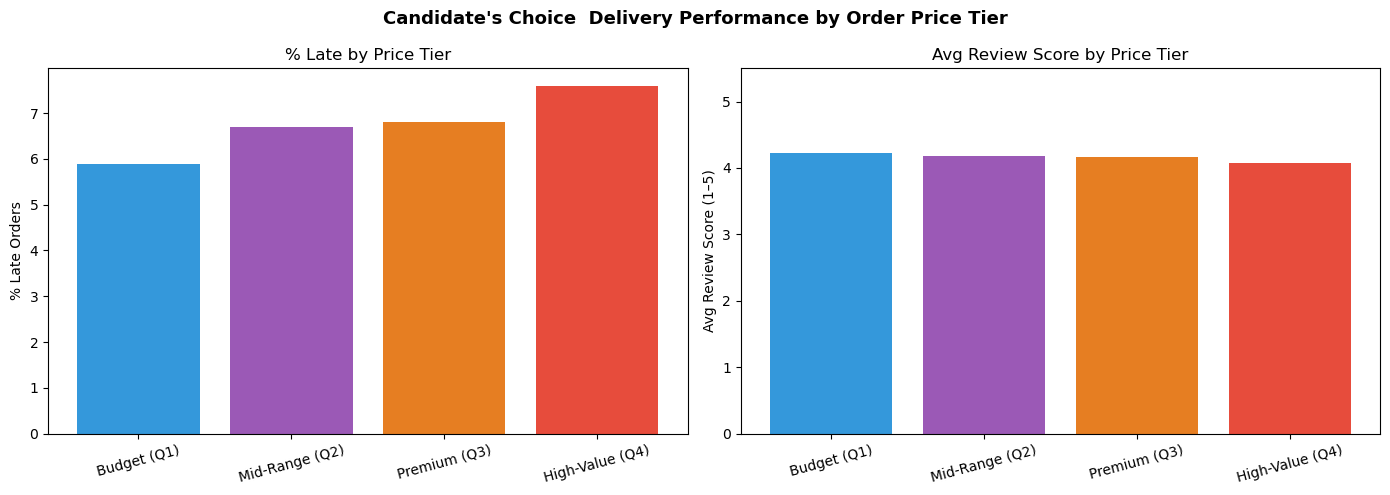

In [17]:
# We create a figure with two subplots: a bar chart to show the percentage of late orders by price tier and another bar chart to show the average review score by price tier. We use a consistent color palette for both charts and annotate the bars with their respective values for clarity. This visualization helps us understand how delivery performance and customer satisfaction vary across different price segments, allowing us to identify if higher-priced orders are associated with better or worse outcomes.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Candidate's Choice  Delivery Performance by Order Price Tier",
             fontsize=13, fontweight='bold')
# We define a color palette for the price tiers to maintain visual consistency across both charts, using shades of blue and red to represent different levels of performance. This helps viewers quickly associate colors with specific price tiers and enhances the overall readability of the visualization.
tier_colors = ['#3498db', '#9b59b6', '#e67e22', '#e74c3c']
# We create a bar chart to visualize the percentage of late orders for each price tier, using the defined color palette. We set the y-axis label and title for clarity, and we rotate the x-axis labels slightly to prevent overlap and improve readability. This chart allows us to quickly see how the percentage of late orders varies across different price segments.
axes[0].bar(tier_stats['price_tier'], tier_stats['pct_late'], color=tier_colors)
axes[0].set_ylabel('% Late Orders')
axes[0].set_title('% Late by Price Tier')
axes[0].tick_params(axis='x', rotation=15)
# We format the y-axis of the percentage of late orders bar chart to show percentages, making it easier for viewers to interpret the values directly as percentages without having to convert from decimal form.
axes[1].bar(tier_stats['price_tier'], tier_stats['avg_score'], color=tier_colors)
axes[1].set_ylabel('Avg Review Score (1–5)')
axes[1].set_title('Avg Review Score by Price Tier')
axes[1].set_ylim(0, 5.5)
axes[1].tick_params(axis='x', rotation=15)
# We adjust the layout to prevent overlap and save the figure as a PNG file with a descriptive name, ensuring that the visualization is clear and can be easily shared or included in reports about delivery performance and customer satisfaction across different price tiers.
plt.tight_layout()
plt.savefig('images/candidates_choice_price_tier.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Export  Power BI / Dashboard CSV
Export the cleaned master dataset as a single CSV for import into Power BI.

In [18]:
# Export master dataset for Power BI
export_cols = [
    'order_id',
    'order_status',
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'days_difference',
    'delivery_status',
    'is_late',
    'review_score',
    'customer_state',
    'customer_city',
    'product_category_name_english',
    'order_value',
    'price_tier',
]
# We create a new DataFrame called export_df that contains only the selected columns from the delivered dataset that are relevant for analysis in Power BI. We then export this DataFrame to a CSV file named 'veridi_master_dataset.csv' without the index, making it ready for import into Power BI for further analysis and visualization.
export_df = delivered[export_cols].copy()
export_df.to_csv('veridi_master_dataset.csv', index=False)
print(f'Exported veridi_master_dataset.csv — {len(export_df):,} rows, {len(export_cols)} columns')
print('Ready to import into Power BI.')

Exported veridi_master_dataset.csv — 96,470 rows, 14 columns
Ready to import into Power BI.


In [20]:
#Also export the state-level summary for easy Power BI map visual 
state_stats.to_csv('veridi_state_summary.csv', index=False)
print('Exported veridi_state_summary.csv')
# We export the state-level summary dataset to a CSV file named 'veridi_state_summary.csv' without the index, providing a ready-to-use dataset for creating geographic visualizations in Power BI that can highlight regional differences in delivery performance and customer satisfaction.
print('\n=== SUMMARY ===')
total = len(delivered)
late_total = delivered['is_late'].sum()
print(f'Total delivered orders analysed: {total:,}')
print(f'Late orders (any): {late_total:,} ({late_total/total*100:.1f}%)')
print(f'Super late (>5d):  {(delivered["delivery_status"]=="Super Late").sum():,}')
print(f'Avg review score  On Time:    {sentiment_by_status.loc["On Time", "avg_score"] if "On Time" in sentiment_by_status.index else "N/A"}')
print(f'Avg review score  Late:       {sentiment_by_status.loc["Late", "avg_score"] if "Late" in sentiment_by_status.index else "N/A"}')
print(f'Avg review score  Super Late: {sentiment_by_status.loc["Super Late", "avg_score"] if "Super Late" in sentiment_by_status.index else "N/A"}')
print(f'Worst state:  {state_stats.iloc[0]["customer_state"]} ({state_stats.iloc[0]["pct_late"]}% late)')
print(f'Best state:   {state_stats.iloc[-1]["customer_state"]} ({state_stats.iloc[-1]["pct_late"]}% late)')

Exported veridi_state_summary.csv

=== SUMMARY ===
Total delivered orders analysed: 96,470
Late orders (any): 6,534 (6.8%)
Super late (>5d):  3,764
Avg review score  On Time:    4.29
Avg review score  Late:       2.99
Avg review score  Super Late: 1.74
Worst state:  AL (21.4% late)
Best state:   AM (2.8% late)
